In [1]:
import os 
import numpy as np
import sqlite3 as sql
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [18]:
data_path = "Z:/giocomo/esay/hipposs/social_interaction_data/behavior/test_novel_object/28_01_2026"
sql_df = sql.connect(os.path.join(data_path, "social_novel_object_2.sqlite"))
df = pd.read_sql('''SELECT * FROM data''',sql_df)

In [19]:
t = df['time'].values
dt = np.diff(t)

fps = 1/np.median(dt)
fps

60.97560975608116

In [20]:
def plot_circular_arc(df, z_threshold=1.0):
    """
    Plot ball position along a circular arc, filtering out paused sections.
    Parameters:
    - df: DataFrame with ball_x, ball_y, ball_z columns
    - z_threshold: minimum z change to consider the ball as moving (cm)
    """
    # Calculate z velocity (change in z)

    # need to calculate diff between ball z and pos
    df['z_diff'] = (df['pos'] - df['ball_z']).abs()
    # Filter: only keep points where ball is actually moving in z
    # (z_diff > threshold means it's moving)
    df_moving = df[df['z_diff'] > z_threshold].copy()
    # Calculate the angle for each point
    # Assuming the center is at x=0 (adjust if needed)
    center_x = df['ball_x'].mean()  # or use a known center point
    center_z = df['ball_z'].mean()
    # Calculate angle from center
    df_moving['angle'] = np.arctan2(df_moving['ball_z'] - center_z,
                                     df_moving['ball_x'] - center_x)
    # Calculate radius from center
    df_moving['radius'] = np.sqrt((df_moving['ball_x'] - center_x)**2 +
                                   (df_moving['ball_z'] - center_z)**2)
    # Plot as polar coordinates or cartesian
    fig, ax = plt.subplots()
    # Plot 1: X-Z plane showing the arc
    ax.scatter(df['ball_x'], df['z_diff'],
                s=20, alpha=0.7)
    ax.set_xlabel('X Position')
    ax.set_ylabel('Z Position')
    ax.set_title('Ball Arc (Moving Points Only)')
    ax.axis('equal')
    ax.grid(True, alpha=0.3)
  
    return df_moving


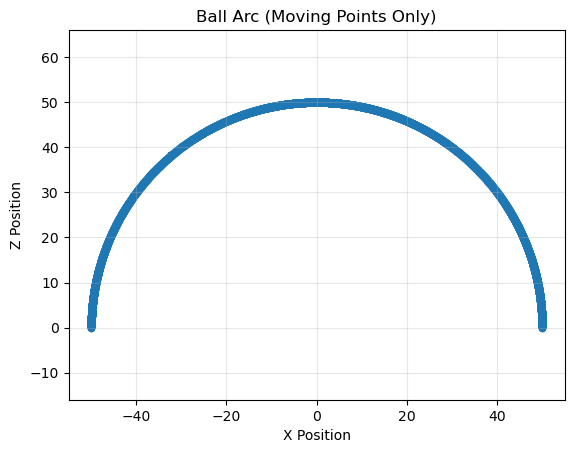

In [21]:
# Use it
df_moving = plot_circular_arc(df, z_threshold=1.0)


In [22]:
# linearize the arc
# arctan(z/x) * r (r=50)

df['linear_pos'] = np.arctan2(df['z_diff'],df['ball_x']) *50


In [23]:
df

,time,morph,trialnum,pos,dz,posx,lick,reward,tstart,teleport,...,manrewards,autoreward,cmd,trainingtrack,norewardSess,ball_x,ball_y,ball_z,z_diff,linear_pos
0,3.199329,0.0,0,-5.0,0.0,0.0,0,0,0,0,...,0,0,2,1,0,-49.99513,16.0,-4.301894,0.698106,156.381504
1,3.209818,0.0,0,-5.0,0.0,0.0,0,0,0,0,...,0,0,2,1,0,-49.98904,16.0,-3.952888,1.047112,156.032444
2,3.619484,0.0,0,-5.0,0.0,0.0,0,0,0,0,...,0,0,2,1,0,-49.52947,16.0,1.843410,6.843410,150.214675
3,3.652168,0.0,0,-5.0,0.0,0.0,0,0,0,0,...,0,0,2,1,0,-49.43536,16.0,2.493000,7.493000,149.558299
4,3.668593,0.0,0,-5.0,0.0,0.0,0,0,0,0,...,0,0,2,1,0,-49.39327,16.0,2.765634,7.765634,149.282435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13033,227.365500,0.0,0,-5.0,0.0,0.0,0,0,0,0,...,0,0,2,1,0,-47.89408,16.0,9.358186,14.358186,142.516408
13034,227.381900,0.0,0,-5.0,0.0,0.0,0,0,0,0,...,0,0,2,1,0,-47.81892,16.0,9.606560,14.606560,142.256910
13035,227.398300,0.0,0,-5.0,0.0,0.0,0,0,0,0,...,0,0,2,1,0,-47.73544,16.0,9.877120,14.877120,141.973764
13036,227.414800,0.0,0,-5.0,0.0,0.0,0,0,0,0,...,0,0,2,1,0,-47.65178,16.0,10.142940,15.142940,141.695090


In [24]:
dt = np.median(np.diff(df['time'].values))
dt

0.01640000000000441

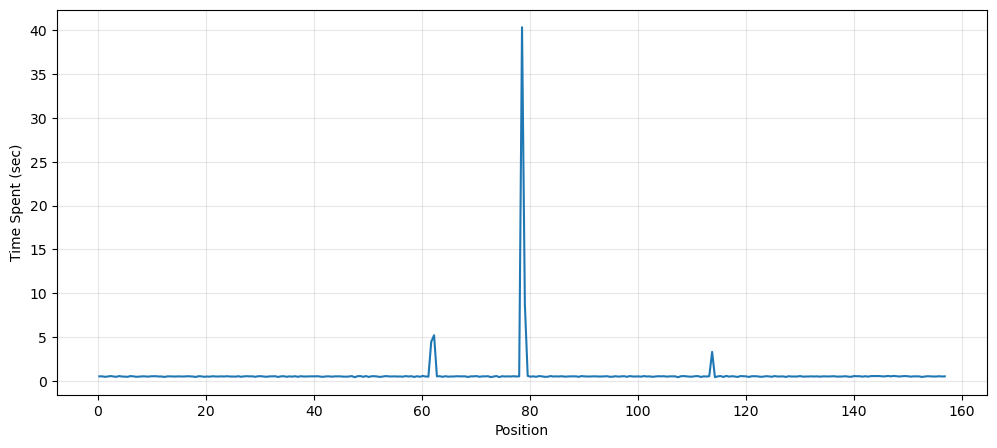

In [27]:
fig, ax = plt.subplots(figsize=(12,5))
bins = np.linspace(df['linear_pos'].min(), df['linear_pos'].max(), 300)
counts, edges = np.histogram(df['linear_pos'], bins = bins)
centers = (edges[:-1] + edges[1:])/2

ax.plot(centers, counts*dt)
ax.set_xlabel("Position")
ax.set_ylabel("Time Spent (sec)")
ax.grid(True, alpha = 0.3)

In [28]:
# calculate speed of the ball 

# pos = df['linear_pos'].values
speed = np.diff(df['linear_pos'].values)/dt



In [29]:
df['ball_speed'] = np.zeros
df['ball_speed'][0]=0
df['ball_speed'][1:] = speed
# df['ball_speed'][2]=0

C:\Users\esay\AppData\Local\Temp\ipykernel_20408\2356458018.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ball_speed'][0]=0
C:\Users\esay\AppData\Local\Temp\ipykernel_20408\2356458018.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ball_speed'][1:] = speed


In [30]:
for i in range(len(df['ball_speed'])):
    if df['ball_speed'][i] < -100:
        df ['ball_speed'][i] = 0

C:\Users\esay\AppData\Local\Temp\ipykernel_20408\2550831069.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df ['ball_speed'][i] = 0


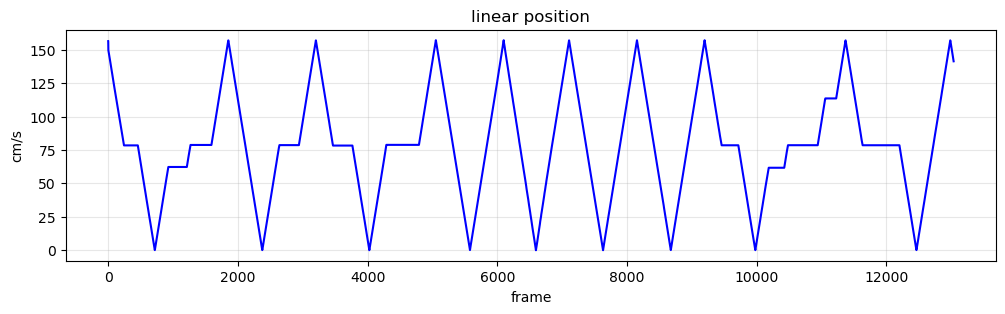

In [32]:
fig, ax = plt.subplots(figsize=(12,3))
ax.plot(df['linear_pos'], color = 'blue')

# ax.plot(df['ball_speed'],color = "orange",
#             alpha=0.7)
ax.set_xlabel('frame')
ax.set_ylabel('cm/s')
ax.set_title('linear position')
ax.grid(True, alpha=0.3)

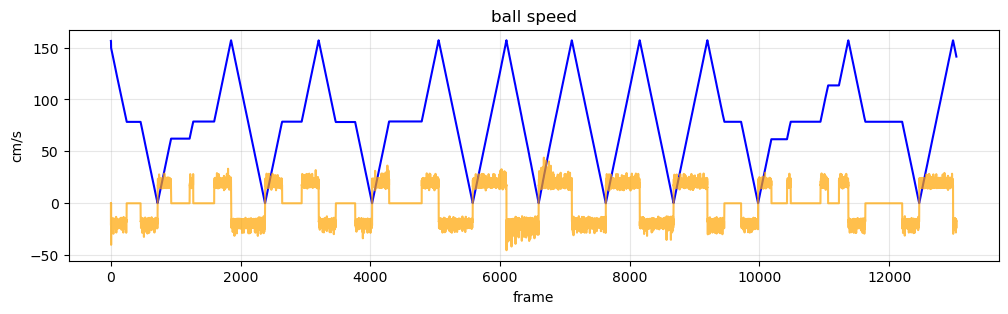

In [33]:
fig, ax = plt.subplots(figsize=(12,3))
ax.plot(df['linear_pos'], color = 'blue')

ax.plot(df['ball_speed'],color = "orange",
            alpha=0.7)
ax.set_xlabel('frame')
ax.set_ylabel('cm/s')
ax.set_title('ball speed')
ax.grid(True, alpha=0.3)

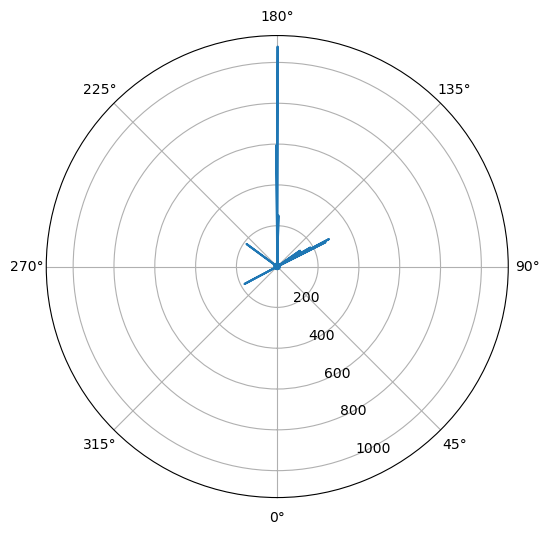

In [17]:
pos = df['linear_pos'].values
theta = 2 * np.pi * (pos-pos.min()) / (pos.max() - pos.min())

n_bins=2000
bins = np.linspace(0,2*np.pi, n_bins + 1)
counts, edges  = np.histogram(theta, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, polar=True)
ax.plot(centers, counts)
ax.fill(centers, counts, alpha=0.3)

ax.set_theta_zero_location('S')